In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from datetime import datetime
import re
from pathlib import Path

In [16]:
caminhos = {
    "Monitoramento": Path() / "Versao_2024",

}

padroes = {
    "Nome do Arquivo": re.compile(r"(\d{4})\s(\d{8})"),
    "belt_speed": re.compile(r'([\d,\.]+): Stacker Diag: Belt Speed ips; section (\d+)[^;]*; T1:([\d\.]+) T2:([\d\.]+)'),
    "belt_speed_extra": re.compile(r'([\d,\.]+): Stacker Diag: Belt Speed ips; the LDU; T1:([\d\.]+) T2:([\d\.]+) T5:([\d\.]+)'),
    "slowest_speed": re.compile(r'([\d,\.]+): Stacker Diag: Slowest Speed in section (\d+) .* is: (\d+) mm/sec'),
    "temperature": re.compile(r'([\d,\.]+): Stacker Diag: Temperature Celsius; section (\d+)[^;]* is: (\d+)'),
    "falha_na_decodificacao": re.compile(
        r"(?P<timestamp>[\d,\.]+):(?: Stacker Diag: Belt Speed ips; section (?P<section>\d+)[^;]*;)?\s?"
        r"(?:T1:(?P<T1>[^\s]+)\s)?T2:(?P<T2>[^\s]+)\sResponse=(?P<response>\w+)"
    )
}

In [17]:
# prompt: listas arquivos em diretório

def listarArquivos(dir: Path)-> list:
  listaArquivos = []
  for file in os.listdir(dir):
    listaArquivos.append(file)

  return listaArquivos


In [18]:
# prompt: ler arquivo linha a linha

def lerArquivo(dir: Path):
  def arquivo(file: str) -> pd.DataFrame:
    data = []
  
    with open(dir / file, "r", encoding="utf-8") as arquivo:
      for linha in arquivo:
        linha = linha.strip()
        for key, pattern in padroes.items():
          match = pattern.match(linha)
          if match:
            if key == "belt_speed":
              timestamp, section, t1, t2 = match.groups()
              data.append({"TimeStamp": timestamp, 
                            "Type": "Belt Speed", 
                            "Section": section,
                            "T1": t1, "T2": t2
              })
            elif key == "belt_speed_extra":
              timestamp, t1, t2, t5 = match.groups()
              data.append({"TimeStamp": timestamp,
                            "Type": "Belt Speed (LDU)",
                            "T1": t1, "T2": t2, "T5": t5
              })
            elif key == "slowest_speed":
              timestamp, section, speed = match.groups()
              data.append({"TimeStamp": timestamp,
                            "Type": "Slowest Speed",
                            "Section": section,
                            "Speed (mm/sec)": speed
              })
            elif key == "temperature":
              timestamp, section, temp = match.groups()
              data.append({"TimeStamp": timestamp,
                            "Type": "Temperature",
                            "Section": section,
                            "Temperature (C)": temp
              })
            elif key == "falha_na_decodificacao":
              match_dict = match.groupdict()
              print(f"Linha Correspondida: {linha.strip()}")  # Depuração
              print(f"Grupos Capturados: {match_dict}")       # Depuração
              data.append({"TimeStamp": match_dict["timestamp"],
                           "Type": "Falha na Decodificação",
                           "Section": match_dict.get("section"),
                           "T1": match_dict.get("T1"), "T2": match_dict["T2"], 
                           "Resposta": match_dict["response"]
              })
              
    df = pd.DataFrame(data)
    return df
  return arquivo


# Extrair parte do texto, conforme o padrão informado

In [19]:
def extrairInformacoes(padrao):
  def definindoTexto(texto):
    return padrao.match(texto).groups()
  return definindoTexto

# Formatar a data para o padrão do Python

In [20]:
def formatarData(data):
  dt = datetime.strptime(data, "%m%d%Y").date()
  return dt

# Processando os Registros

In [21]:
arquivos = listarArquivos(caminhos["Monitoramento"])
mainDataFrame = pd.DataFrame()
definir_local_para_leitura_dos_arquivos = lerArquivo(caminhos["Monitoramento"])
definir_padrao_para_extracao_do_nome_da_maquina_e_da_data = extrairInformacoes(padroes['Nome do Arquivo'])

for arquivo in arquivos:
  dados = definir_local_para_leitura_dos_arquivos(arquivo)
  maquina, date = definir_padrao_para_extracao_do_nome_da_maquina_e_da_data(arquivo)
  date = formatarData(date)
  dados["Máquina"] = maquina
  dados["Data"] = date
  mainDataFrame = pd.concat([mainDataFrame, dados])

mainDataFrame.set_index(["Data"], inplace = True)
mainDataFrame

,TimeStamp,Type,Section,T1,T2,T5,Speed (mm/sec),Temperature (C),Máquina
Data,,,,,,,,,
2024-09-02,"2,938,959.365",Belt Speed,18,186.2,185.8,NaN,NaN,NaN,4086
2024-09-02,"2,939,411.393",Belt Speed,19,186.6,185.0,NaN,NaN,NaN,4086
2024-09-02,"2,939,883.433",Belt Speed,20,185.8,186.2,NaN,NaN,NaN,4086
2024-09-02,"2,940,370.030",Belt Speed,21,185.4,185.8,NaN,NaN,NaN,4086
2024-09-02,"2,940,869.548",Belt Speed,22,185.8,185.8,NaN,NaN,NaN,4086
...,...,...,...,...,...,...,...,...,...
2024-12-10,"4,149,374.876",Temperature,17,NaN,NaN,NaN,NaN,30,4088
2024-12-10,"4,149,411.887",Temperature,19,NaN,NaN,NaN,NaN,30,4088
2024-12-10,"4,149,419.355",Temperature,23,NaN,NaN,NaN,NaN,30,4088


In [22]:
teste = mainDataFrame.loc[mainDataFrame['Type'] == 'falha_na_decodificacao']
teste

,TimeStamp,Type,Section,T1,T2,T5,Speed (mm/sec),Temperature (C),Máquina
Data,,,,,,,,,


In [23]:
velocidadeDasCorreias = mainDataFrame.loc[mainDataFrame['Type'] == 'Belt Speed'].copy(deep = True)
velocidade_das_correias_LDU = mainDataFrame.loc[mainDataFrame['Type'] == 'Belt Speed (LDU)'].copy(deep = True)
secoes_apresentando_lentidao = mainDataFrame.loc[mainDataFrame['Type'] == 'Slowest Speed'].copy(deep = True)
temperaturaDosSensores = mainDataFrame.loc[mainDataFrame['Type'] == 'Temperature'].copy(deep = True)

In [24]:
velocidadeDasCorreias.drop(columns = ['TimeStamp', 'Type', 'T5', 'Speed (mm/sec)', 'Temperature (C)'], inplace=True)
velocidadeDasCorreias.drop_duplicates(inplace=True)
velocidadeDasCorreias = velocidadeDasCorreias.astype({
    'Section': 'int8', 'T1': 'float', 'T2': 'float', 'Máquina': 'int16'
})
velocidadeDasCorreias

,Section,T1,T2,Máquina
Data,,,,
2024-09-02,18,186.2,185.8,4086
2024-09-02,19,186.6,185.0,4086
2024-09-02,20,185.8,186.2,4086
2024-09-02,21,185.4,185.8,4086
2024-09-02,22,185.8,185.8,4086
...,...,...,...,...
2024-12-10,4,186.6,185.8,4088
2024-12-10,8,185.8,185.4,4088
2024-12-10,2,186.2,186.2,4088


In [25]:
velocidade_das_correias_LDU.drop(columns = ['TimeStamp', 'Type', 'Section', 'Speed (mm/sec)', 'Temperature (C)'], inplace=True)
velocidade_das_correias_LDU.drop_duplicates(inplace=True)
velocidade_das_correias_LDU = velocidade_das_correias_LDU.astype({
    'T1': 'float', 'T2': 'float', 'T5': 'float', 'Máquina': 'int16'
})
velocidade_das_correias_LDU

,T1,T2,T5,Máquina
Data,,,,
2024-09-02,187.8,187.8,183.9,4086
2024-09-02,187.8,187.8,183.5,4086
2024-09-02,188.2,188.2,183.9,4086
2024-09-02,188.6,187.8,183.5,4086
2024-09-02,188.6,188.2,184.3,4086
...,...,...,...,...
2024-10-28,188.6,187.4,181.9,4088
2024-10-28,189.0,187.4,182.3,4088
2024-11-06,188.6,187.0,182.3,4088


In [26]:
secoes_apresentando_lentidao.drop(columns = ['TimeStamp', 'Type', 'T1', 'T2', 'T5', 'Temperature (C)'], inplace=True)
secoes_apresentando_lentidao.drop_duplicates(inplace=True)
secoes_apresentando_lentidao = secoes_apresentando_lentidao.astype({
    'Section': 'int8', 'Speed (mm/sec)': 'int16', 'Máquina': 'int16'
})
secoes_apresentando_lentidao

,Section,Speed (mm/sec),Máquina
Data,,,
2024-09-02,6,4574,4086
2024-09-02,3,4591,4086
2024-09-02,12,4543,4086
2024-09-05,23,4648,4086
2024-09-05,7,4566,4086
...,...,...,...
2024-12-09,19,4536,4088
2024-12-09,22,4545,4088
2024-12-09,25,4557,4088


In [27]:
temperaturaDosSensores.drop(columns = ['TimeStamp', 'Type', 'T1', 'T2', 'T5', 'Speed (mm/sec)'], inplace=True)
temperaturaDosSensores.drop_duplicates(inplace=True)
temperaturaDosSensores = temperaturaDosSensores.astype({
    'Section': 'int8', 'Temperature (C)': 'int8', 'Máquina': 'int16'
})
temperaturaDosSensores

,Section,Temperature (C),Máquina
Data,,,
2024-09-02,8,29,4086
2024-09-02,2,29,4086
2024-09-02,3,29,4086
2024-09-02,10,29,4086
2024-09-02,5,30,4086
...,...,...,...
2024-11-22,1,25,4088
2024-11-22,2,25,4088
2024-11-22,22,25,4088


### Criar os gráficos

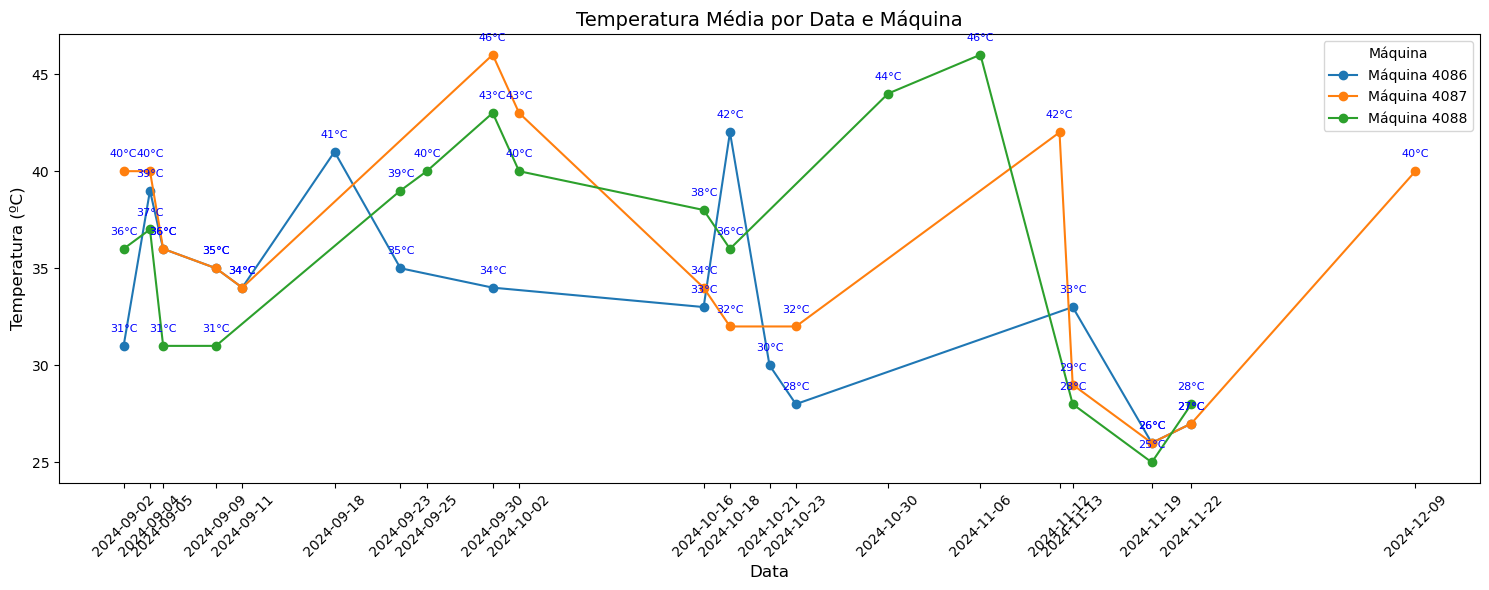

In [28]:
fig, ax = plt.subplots(figsize = (15, 6))

plot_data = []

for maquina, grupo in temperaturaDosSensores.groupby('Máquina'):
    max_temps = grupo.groupby('Data')['Temperature (C)'].max()
    line, = ax.plot(max_temps.index, max_temps.values, marker = 'o', label=f'Máquina {maquina}', picker = 5)

    # Adicionar lembretes para cada ponto
    for i, (data, temp) in enumerate(max_temps.items()):
        ax.annotate(
            f"{temp}°C",  # Texto do lembrete
            (data, temp),  # Posição do ponto
            textcoords="offset points",  # Coordenadas relativas ao ponto
            xytext=(0, 10),  # Offset do texto (x=0, y=10 pixels acima)
            ha='center',  # Alinhamento horizontal
            fontsize=8,  # Tamanho da fonte
            color='blue'  # Cor do texto
        )
    
    plot_data.append({
        'line': line,
        'data': max_temps,
        'original': grupo
    })

# Configurações do gráfico
plt.title("Temperatura Média por Data e Máquina", fontsize = 14)
plt.xlabel('Data', fontsize = 12)
plt.ylabel('Temperatura (ºC)', fontsize = 12)
plt.grid(False)
plt.legend(title = "Máquina")
#plt.xticks(rotation = 45)

all_dates = sorted(set(temperaturaDosSensores.index))
ax.set_xticks(all_dates)
ax.set_xticklabels(all_dates, rotation=45, fontsize=10)
plt.tight_layout()


# Função para tratar cliques
def on_pick(event):
    clicked_line = event.artist # Linha clicada
     # Indice do ponto clicado
    for entry in plot_data:
        if entry['line'] == clicked_line:
            # Obter os índices do ponto clicado
            ind = event.ind[0]

            # Dados agrupados (plotados)
            plot_data_agg = entry['data']

            # Obtem a data e temperatura do ponto clicado
            data_clicada = plot_data_agg.index[ind]
            temp_clicada = plot_data_agg.iloc[ind]
            
            # Encontrar os dados originais correspondentes à data clicada
            grupo_original = entry['original']
            detalhes = grupo_original[grupo_original['Data'] == data_clicada]

            # Exibir detalhes no console
            print(f"Máquina: {entry['line'].get_label()}")  # Exibe a máquina
            print(f"Data clicada: {data_clicada}, Temperatura máxima: {temp_clicada}°C")
            print("Detalhes adicionais:")
            for _, detalhe in detalhes.iterrows():
                print(f'Detalhes: Máquina {detalhe["Máquina"]}, Data {detalhe["Data"]}, Temperatura {detalhe["Temperature (C)"]}ºC, Seção {detalhe["Section"]}')

# Conectar o evento ao gráfico
fig.canvas.mpl_connect('pick_event', on_pick)

# Exibir o gráfico
plt.show()